In [1]:
import sys
sys.path.append('../src')

In [2]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from stock_prices import get_stock_prices, plot_stock_prices, split_train_test
from feature_extraction import add_state_column
from technical_indicator_classifier import TechnicalIndicatorClassifier
from hybrid_model import HybridModel
from simulation import simulate_trade

In [21]:
symbol = "BRMS.JK"
start_date = "2023-01-01"
split_date = "2024-12-31"
end_date = "2025-12-31"

$BRMS.JK: possibly delisted; no price data found  (1d 2023-01-01 -> 2023-01-02)


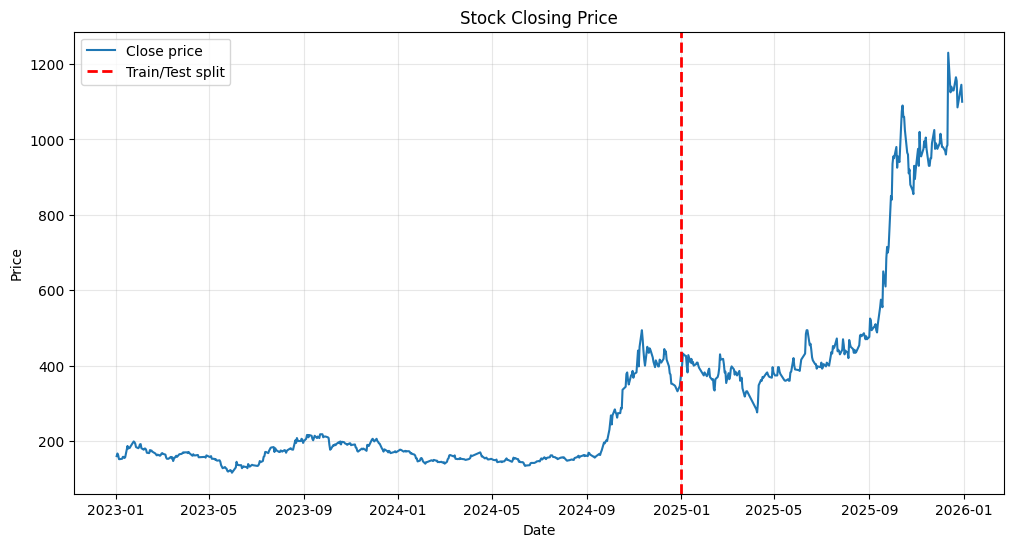

,symbol,date,open,high,low,close,volume,dividends,stock_splits
0,BRMS.JK,2023-01-02,162.0,163.0,159.0,160.0,71224000,0.0,0.0
1,BRMS.JK,2023-01-03,161.0,171.0,159.0,167.0,482644400,0.0,0.0
2,BRMS.JK,2023-01-04,169.0,169.0,162.0,162.0,228361800,0.0,0.0
3,BRMS.JK,2023-01-05,162.0,165.0,151.0,152.0,535938800,0.0,0.0
4,BRMS.JK,2023-01-06,152.0,154.0,147.0,152.0,75497200,0.0,0.0


In [22]:
stock_prices = get_stock_prices(symbol, start_date, end_date)
plot_stock_prices(stock_prices, split_date)
stock_prices.head()

In [23]:
add_state_column(stock_prices)
stock_prices_train, stock_prices_test = split_train_test(stock_prices, split_date)

In [24]:
method = "GaussianNB"
peek = 7
k = 9

In [25]:
classifier = TechnicalIndicatorClassifier(model = method, peek = peek)
classifier.train(stock_prices_train)

In [26]:
np.random.seed(5)
hybrid_model = HybridModel(k = k, classifier = classifier)
hybrid_model.train(stock_prices_train)

Epoch 301: Total reward = 1.562, Past Ten Total Rewards Std = 0.05531465239801653
Epoch 302: Total reward = 1.556, Past Ten Total Rewards Std = 0.05541480050040219
Epoch 303: Total reward = 1.435, Past Ten Total Rewards Std = 0.053985676234025275
Epoch 304: Total reward = 1.545, Past Ten Total Rewards Std = 0.06338785379613013
Epoch 305: Total reward = 1.423, Past Ten Total Rewards Std = 0.05003547310851495
Epoch 306: Total reward = 1.478, Past Ten Total Rewards Std = 0.05902029022822143
Epoch 307: Total reward = 1.602, Past Ten Total Rewards Std = 0.05634366690551653
Epoch 308: Total reward = 1.482, Past Ten Total Rewards Std = 0.061884378195976954
Epoch 309: Total reward = 1.536, Past Ten Total Rewards Std = 0.06034714706841136
Epoch 310: Total reward = 1.539, Past Ten Total Rewards Std = 0.05537701049839572
Epoch 311: Total reward = 1.523, Past Ten Total Rewards Std = 0.05522473390803113
Epoch 312: Total reward = 1.532, Past Ten Total Rewards Std = 0.05320839090520699
Epoch 313: Tot

True

Accumulated returns on training data:
Buy and hold return:  0.7093402061855669


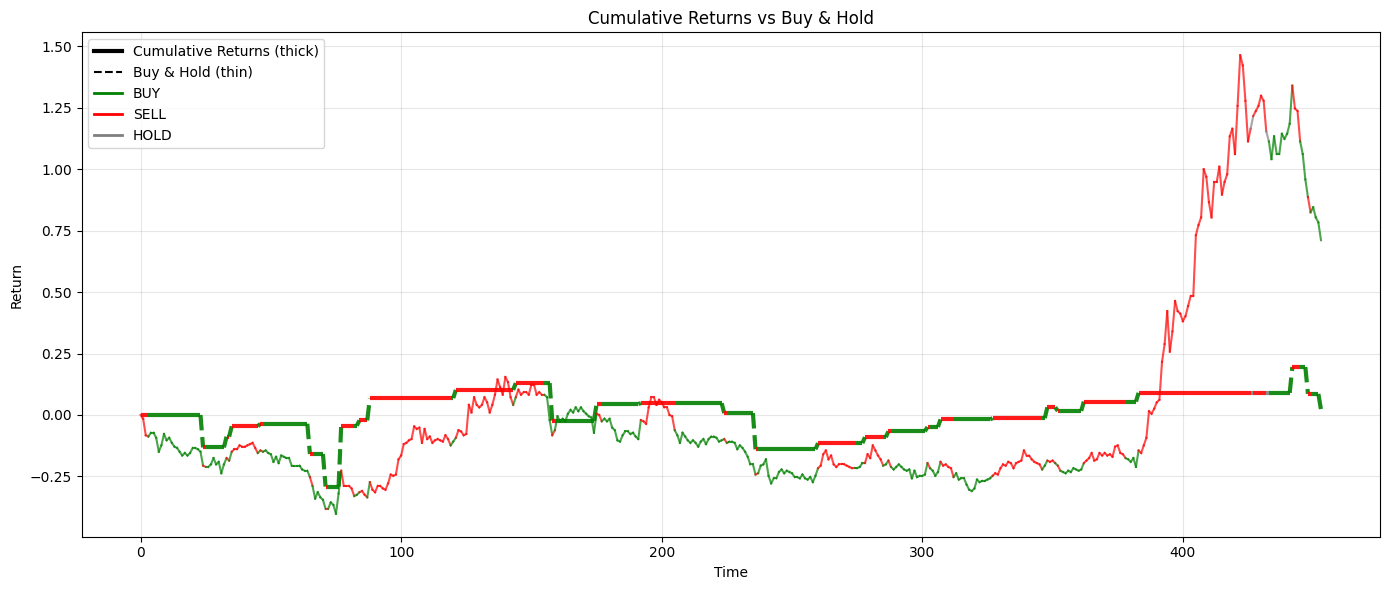

MA based return: 0.021891846859970004


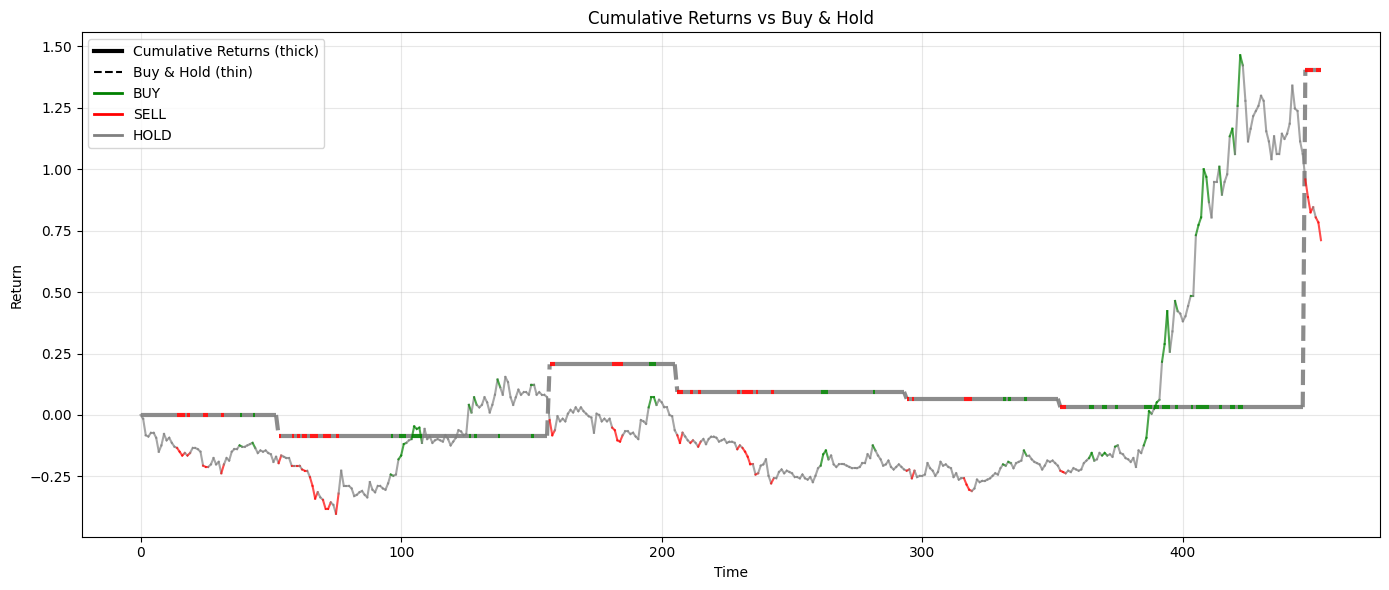

Breakout based return: 1.4049319751360956


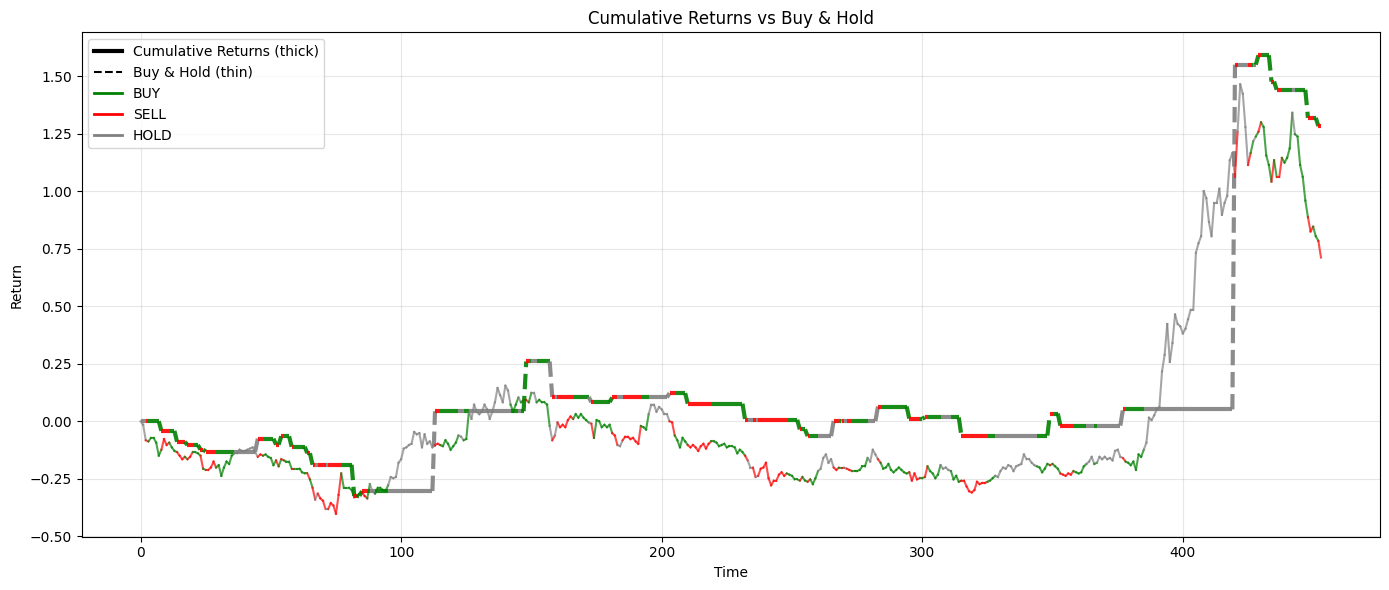

Classifier model return: 1.2825503905589877


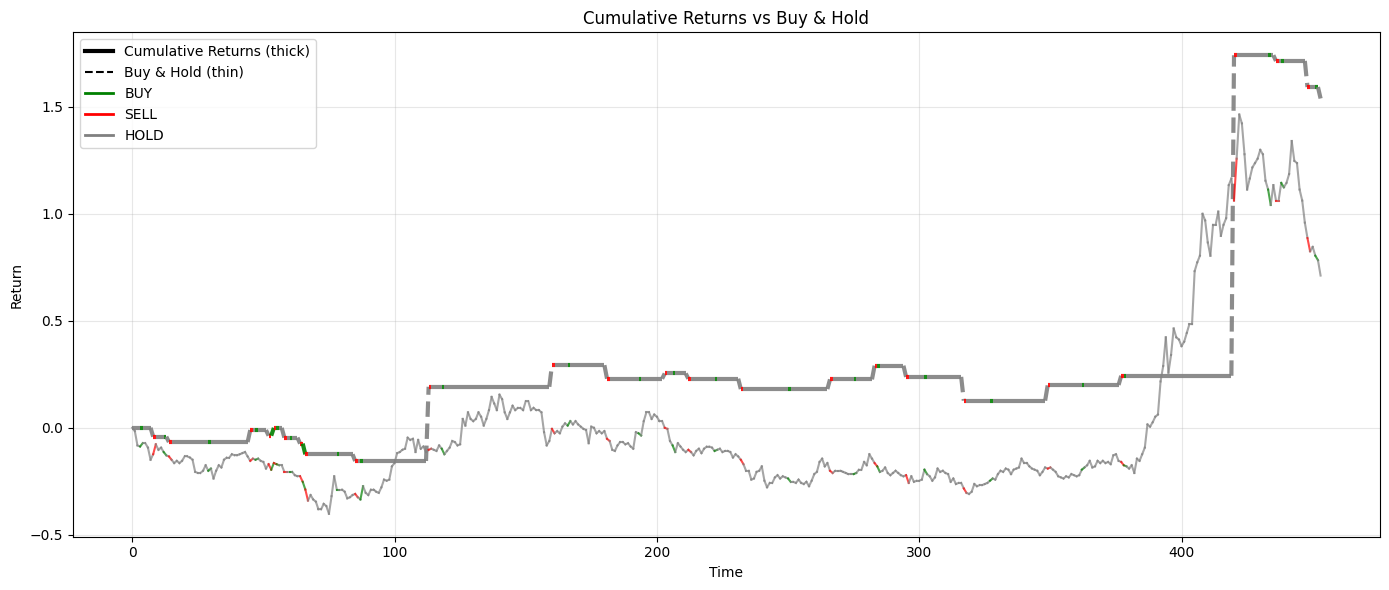

Hybrid model return: 1.5389774259768427


In [27]:
train_result = {}
print("Accumulated returns on training data:")
open_prices_train = stock_prices_train["open"].values[20:]

train_result["buy and hold"] = (open_prices_train[-1] / open_prices_train[1] - 1.002)
print("Buy and hold return: ", train_result["buy and hold"])

train_result["ma"] = simulate_trade(stock_prices_train, "ma", plot = True)
print("MA based return:", train_result["ma"])

train_result["breakout"] = simulate_trade(stock_prices_train, "breakout", plot = True)
print("Breakout based return:", train_result["breakout"])

train_result["classifier"] = simulate_trade(stock_prices_train, classifier, plot = True)
print("Classifier model return:", train_result["classifier"])

if k != 0:
    train_result["hybrid"] = simulate_trade(stock_prices_train, hybrid_model, plot = True)
    print("Hybrid model return:", train_result["hybrid"])

Accumulated returns on test data:
Buy and hold return:  1.730843137254902


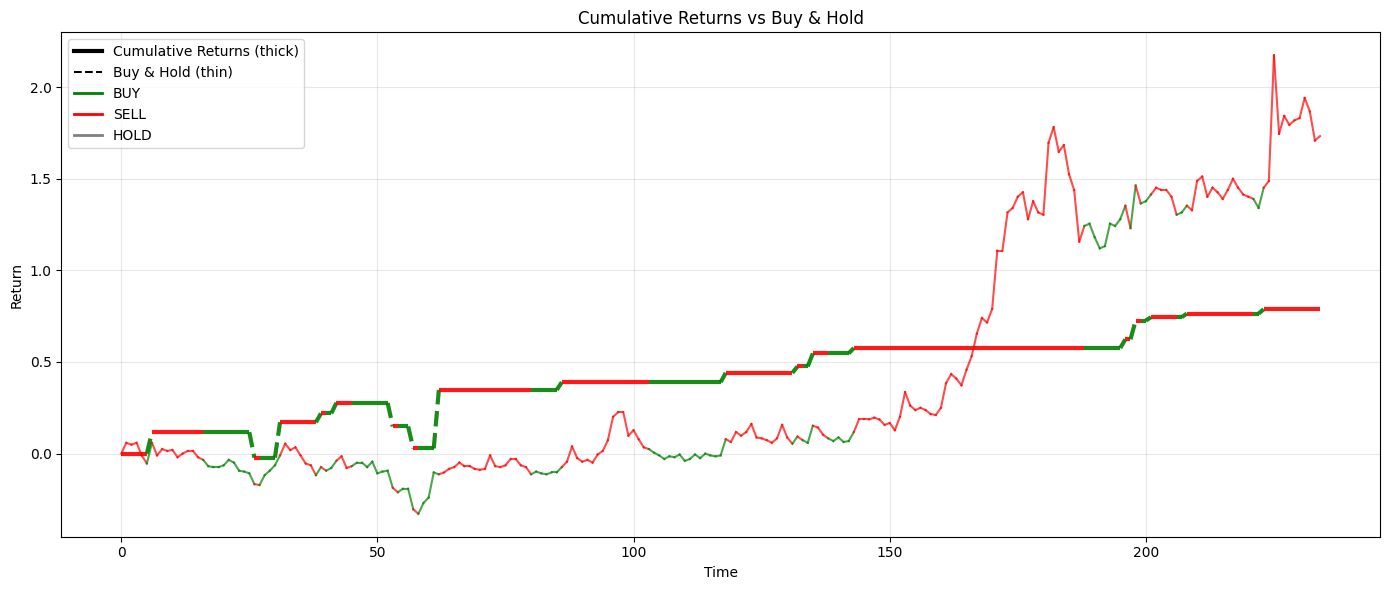

MA only return: 0.7876728373462252


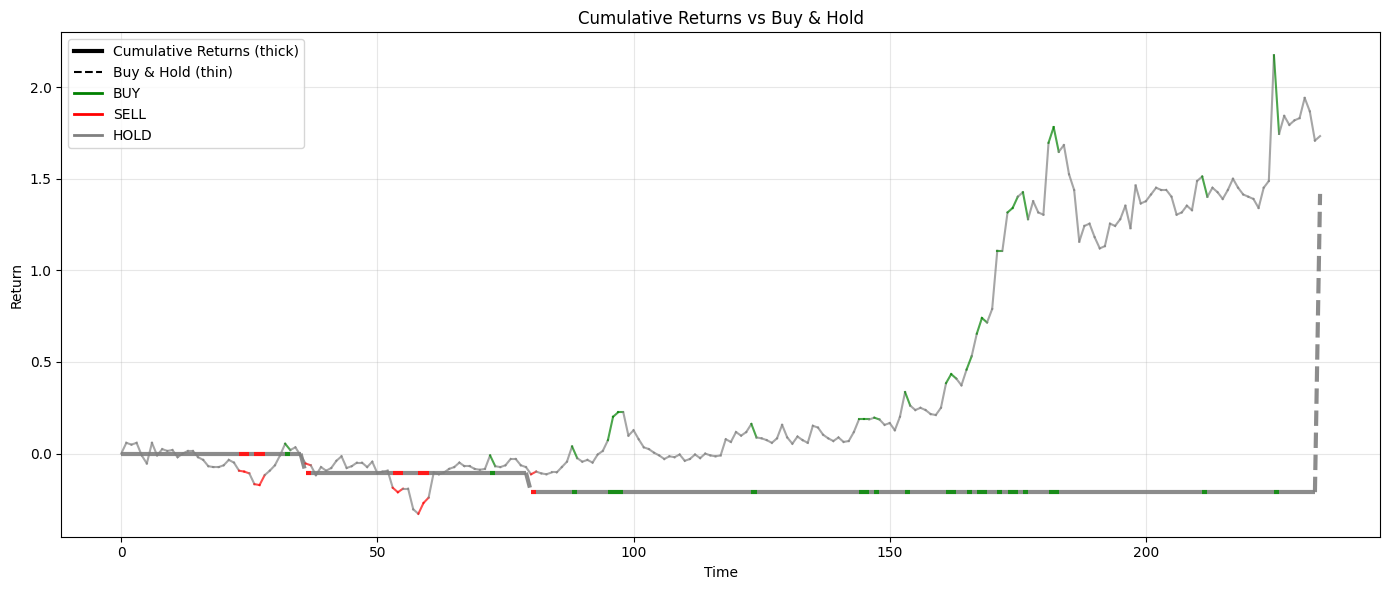

Breakout based return: 1.4174310036971227


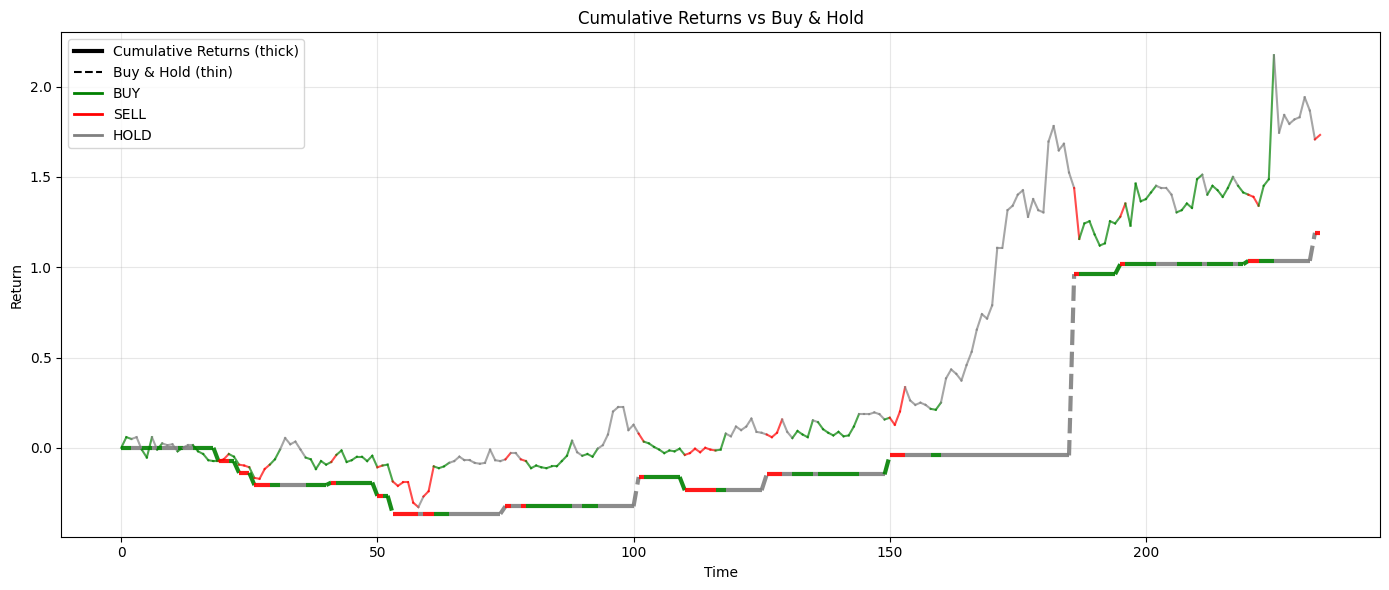

Classifier model return: 1.1905282862384605


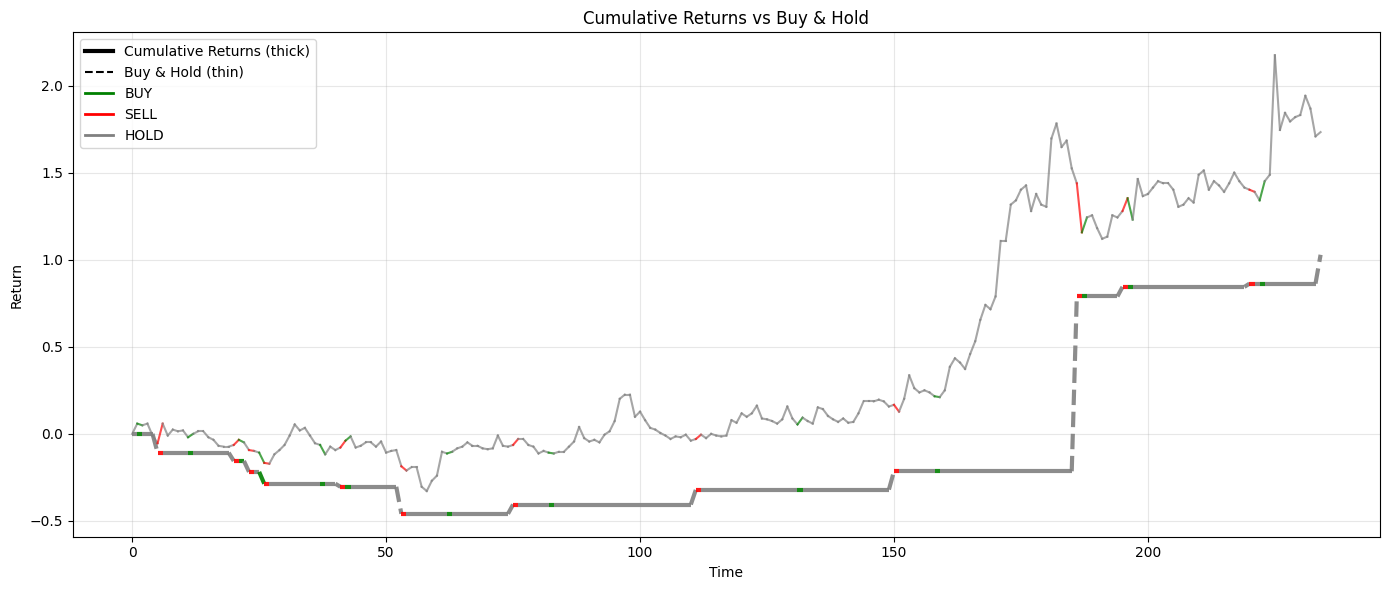

Hybrid model return: 1.0282793363748388


In [28]:
test_result = {}
print("Accumulated returns on test data:")
open_prices_test = stock_prices_test["open"].values[20:]

test_result["buy and hold"] = (open_prices_test[-1] / open_prices_test[1] - 1.002)
print("Buy and hold return: ", test_result["buy and hold"])

test_result["ma"] = simulate_trade(stock_prices_test, "ma", plot = True)
print("MA only return:", test_result["ma"])

test_result["breakout"] = simulate_trade(stock_prices_test, "breakout", plot = True)
print("Breakout based return:", test_result["breakout"])

test_result["classifier"] = simulate_trade(stock_prices_test, classifier, plot = True)
print("Classifier model return:", test_result["classifier"])

if k != 0:
    test_result["hybrid"] = simulate_trade(stock_prices_test, hybrid_model, plot = True)
    print("Hybrid model return:", test_result["hybrid"])

In [29]:
def run_iteration(i):
    np.random.seed(i)
    hybrid_model = HybridModel(k = k, classifier = classifier)
    stable = hybrid_model.train(stock_prices_train, show_log = False)
    trial = 1
    while not stable:
        stable = hybrid_model.train(stock_prices_train, show_log = False)
        trial += 1
        if trial == 10:
            print(f"Model failed to stabilize even after 10 trials (seed {i})")
            # Only account instance which achieves pseudo-convergence before max epochs
            return None
    test_ret = simulate_trade(stock_prices_test, hybrid_model, plot = False)
    return test_ret

results = Parallel(n_jobs = -1)(delayed(run_iteration)(i) for i in range(6, 21))
results = [result for result in results if result is not None]
hybrid_returns = np.array(results)

buy_hold_return = test_result["buy and hold"]

ma_return = test_result["ma"]
excess_ma = ma_return - buy_hold_return

break_out_return = test_result["breakout"]
excess_momentum = break_out_return - buy_hold_return

classifier_return = test_result["classifier"]
excess_classifier = classifier_return - buy_hold_return

mean_hybrid_return = np.mean(hybrid_returns)
hybrid_excess_returns = hybrid_returns - buy_hold_return
excess_hybrid = mean_hybrid_return - buy_hold_return
excess_hybrid_std =  np.std(hybrid_excess_returns)

# Create dataframe with 8 columns
results_df = pd.DataFrame({
    'Buy and Hold': [buy_hold_return],
    'MA Based': [ma_return],
    'Breakout Based': [break_out_return],
    'Classifier Model': [classifier_return],
    'Mean Hybrid Model': [mean_hybrid_return],
    'Excess MA': [excess_ma],
    'Excess Breakout': [excess_momentum],
    'Excess Classifier': [excess_classifier],
    'Excess Hybrid': [excess_hybrid],
    'Excess Hybrid Std': [excess_hybrid_std],
    'Number of Samples': len(hybrid_returns)
})

display(results_df)

results_df.to_parquet(f"results/{symbol[:4]}.parquet", engine = "pyarrow")

,Buy and Hold,MA Based,Breakout Based,Classifier Model,Mean Hybrid Model,Excess MA,Excess Breakout,Excess Classifier,Excess Hybrid,Excess Hybrid Std,Number of Samples
0,1.730843,0.787673,1.417431,1.190528,0.852224,-0.94317,-0.313412,-0.540315,-0.878619,0.401807,15
